![jupyter](img/logo-itq.png)

# Variable_cuantitativa  
## PAO26-27 - Python 01

![jupyter](img/logo-py.png)

**Nombre:** *David Ruiz*
Variable_cuantitativa 

In [2]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [3]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [4]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


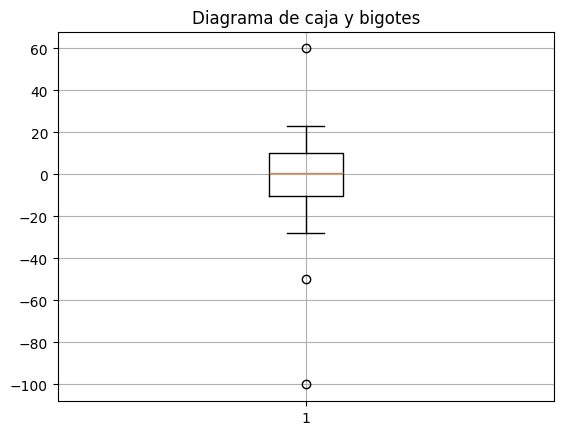

In [5]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [6]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [14]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
## Importante para saber cual debemos seleccionar del petalo y el sepalo
##pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?

petalo_largo = X[:, 2]
asimetria_p = stats.skew(petalo_largo)
## Decimales a mostrar
print("La asimetría de la longitud del pétalo es:", np.round(asimetria_p, 4))

if asimetria_p > 0:
    print("Es positivo")
elif asimetria_p < 0:
    print("Es negativo")
else:
    print("Es simétrica.")

# A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?"

ancho_sepalo = X[:, 1]
curtosis_sepalo = stats.kurtosis(ancho_sepalo)
## Decimales a mostrar

print("La curtosis del ancho del sépalo es:", np.round(curtosis_sepalo, 4))

if curtosis_sepalo > 0:
    print("Distribución Leptocúrtica")
elif curtosis_sepalo < 0:
    print("Distribución Platicúrtica")
else:
    print("Distribución Mesocúrtica")

La asimetría de la longitud del pétalo es: -0.2721
Es negativo
La curtosis del ancho del sépalo es: 0.181
Distribución Leptocúrtica


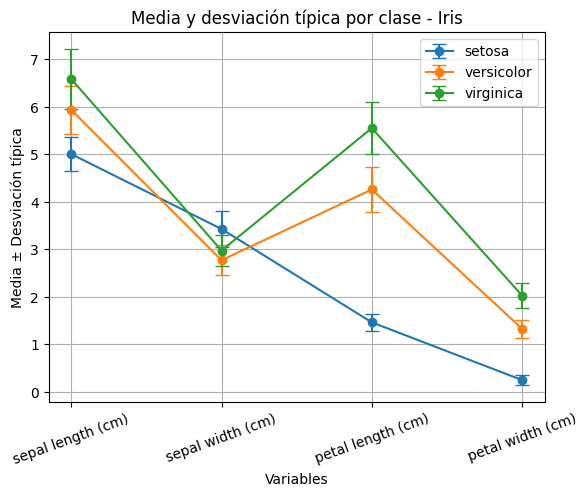

In [16]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
import matplotlib.pyplot as plt
import numpy as np

nombres_variables = iris.feature_names
nombres_clases = iris.target_names

plt.figure()

for clase in range(len(nombres_clases)):
    datos_clase = X[y == clase]   # Filtrara los datos en funcion de su clase
    
    media = np.mean(datos_clase, axis=0)   # Media 
    desvest = np.std(datos_clase, axis=0)  # Desviación típica
    
    plt.errorbar(
        x=np.arange(len(nombres_variables)),
        y=media,
        yerr=desvest,
        marker='o',
        capsize=5,
        label=nombres_clases[clase]
    )

plt.xticks(np.arange(len(nombres_variables)), nombres_variables, rotation=20)
plt.xlabel("Variables")
plt.ylabel("Media ± Desviación típica")
plt.title("Media y desviación típica por clase - Iris")
plt.legend()
plt.grid()

plt.show()

### Repositorio
* https://github.com/enderliliessad-pixel/Cuaderno_Machine2.git